##  SPOTIFY MUSIC RECOMMENDATION SYSTEM USING UNSUPERVISED MACHINE LEARNING

### Problem Statement

Music streaming platforms contain millions of songs, making it difficult for users to discover new music that matches their preferences. Traditional search methods require users to know the song or artist beforehand and may not effectively recommend similar songs based on their musical characteristics. Therefore, there is a need for an intelligent recommendation system that can automatically identify and suggest songs with similar audio features, enhancing the overall user listening experience.
    
### Objective 
To perform exploratory data analysis and cluster analysis to create cohorts of songs. The goal is to better understand the various factors that create a cohort of songs.
    
The objective of this project is to develop a content-based music recommendation system using unsupervised machine learning techniques. The project aims to group songs with similar audio characteristics using clustering algorithms and recommend similar songs by measuring feature similarity through cosine similarity. The system is designed to provide meaningful song recommendations based solely on the audio features of the songs.

### Dataset Description

The dataset contains Spotify songs along with their audio features, including danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration, and popularity. These features capture different musical characteristics that can be used to identify similarities between songs.

### Methodology

The project follows the following workflow:

* Data Collection
* Data Preprocessing
* Exploratory Data Analysis (EDA)
* Feature Selection
* Feature Scaling using StandardScaler
* K-Means Clustering
* Elbow Method
* Silhouette Score Analysis
* PCA Visualization
* Cluster Interpretation
* Comparison with DBSCAN and Hierarchical Clustering
* Content-Based Recommendation using Cosine Similarity
* Recommendation Generation

### Machine Learning Techniques Used
* Unsupervised Learning
* K-Means Clustering
* Hierarchical Clustering
* DBSCAN
* Principal Component Analysis (PCA)
* Cosine Similarity for Content based Recommendation

### Expected Outcome

The proposed system is expected to successfully group similar songs into meaningful clusters and recommend songs that share similar audio characteristics with a selected song. By combining clustering and cosine similarity, the recommendation system aims to improve recommendation relevance while reducing unnecessary similarity comparisons.

## WorkFlow

📂 Dataset
      →
🧹 Preprocessing
      →
📊 EDA
      →
⚖️ Feature Scaling
      →
🤖 K-Means Clustering
      →
📈 Elbow & Silhouette
      →
📉 PCA Visualization
      →
📋 Cluster Profiling
      →
📐 Cosine Similarity
      →
🎵 Recommendation System
      →
✅ Top-N Recommendations

In [1]:
#Importing Required Libraries
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [2]:
#Load data from csv
df = pd.read_csv("rolling_stones_spotify.csv")


In [3]:
# Displaying first five rows
df.head()

,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


In [4]:
df.shape

(1610, 18)

In [5]:
# Descriptive statistics of the data
df.describe()


,Unnamed: 0,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,804.500000,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6.971615,0.069512,126.082033,0.582165,20.788199,257736.488199
std,464.911282,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,2.994003,0.051631,29.233483,0.231253,12.426859,108333.474920
min,0.000000,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24.408000,0.023200,46.525000,0.000000,0.000000,21000.000000
25%,402.250000,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8.982500,0.036500,107.390750,0.404250,13.000000,190613.000000
50%,804.500000,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6.523000,0.051200,124.404500,0.583000,20.000000,243093.000000
75%,1206.750000,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4.608750,0.086600,142.355750,0.778000,27.000000,295319.750000
max,1609.000000,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-1.014000,0.624000,216.304000,0.974000,80.000000,981866.000000


In [6]:
#Getting the info about the coulmns datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1610 non-null   int64  
 1   name              1610 non-null   object 
 2   album             1610 non-null   object 
 3   release_date      1610 non-null   object 
 4   track_number      1610 non-null   int64  
 5   id                1610 non-null   object 
 6   uri               1610 non-null   object 
 7   acousticness      1610 non-null   float64
 8   danceability      1610 non-null   float64
 9   energy            1610 non-null   float64
 10  instrumentalness  1610 non-null   float64
 11  liveness          1610 non-null   float64
 12  loudness          1610 non-null   float64
 13  speechiness       1610 non-null   float64
 14  tempo             1610 non-null   float64
 15  valence           1610 non-null   float64
 16  popularity        1610 non-null   int64  


In [7]:
#checking for any missing or null values
df.isnull().sum()

Unnamed: 0          0
name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

In [8]:
#checking for any unique values
df.nunique()

Unnamed: 0          1610
name                 954
album                 90
release_date          57
track_number          47
id                  1610
uri                 1610
acousticness         933
danceability         518
energy               511
instrumentalness    1134
liveness             757
loudness            1329
speechiness          655
tempo               1424
valence              701
popularity            69
duration_ms         1320
dtype: int64

In [9]:
# Dropping the columns which are no longer needed for cluster analysis
data = df.drop(columns=[
    "Unnamed: 0",
    "name",
    "album",
    "release_date",
    "id",
    "uri",
    "track_number"
])

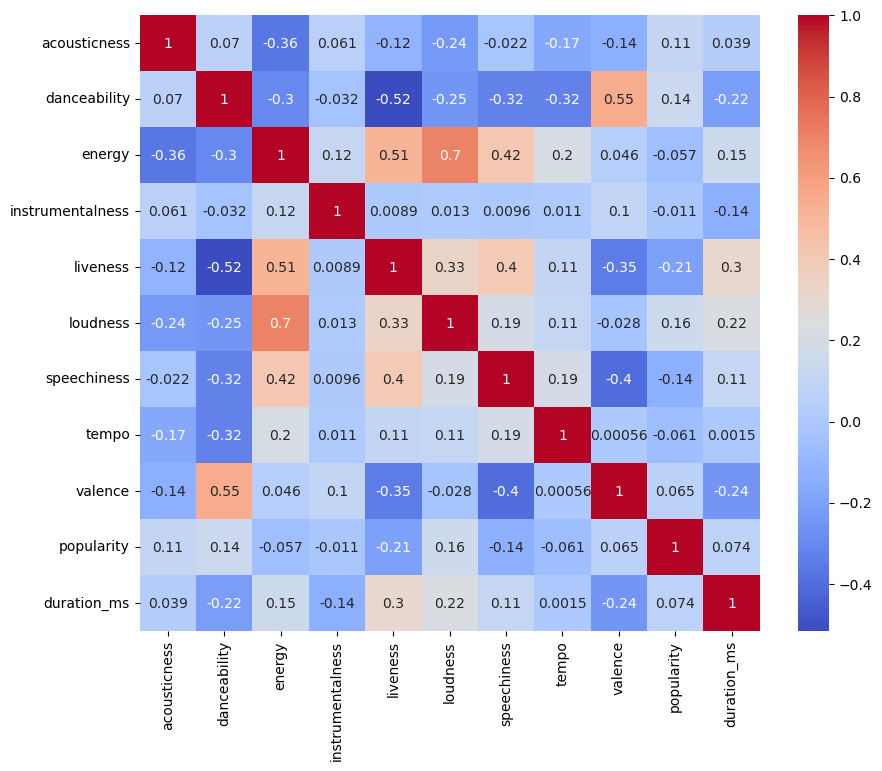

In [10]:
# Checking the correlation among the features
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

### 📊 Correlation Heatmap Observation

A correlation heatmap was generated to examine the relationships among the numerical audio features in the Spotify dataset before feature scaling.
    
The heatmap shows both positive and negative correlations, helping identify how changes in one feature are associated with changes in another.
    
Strong positive correlations were observed between some audio features, indicating that they tend to increase together, while strong negative correlations suggested an inverse relationship.
    
Most features exhibited low to moderate correlations, indicating that they contribute unique information to the clustering process.
    
Since no severe multicollinearity was observed among the selected features, all relevant numerical features were retained for clustering.
    
The heatmap also provided insights into feature dependencies, which helped in understanding the dataset before applying StandardScaler and clustering algorithms.

In [11]:
# Scaling the values beacuse clustering needs to calculate distance
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Lists to store evaluation metrics
wcss = []
silhouette_scores = []

best_score = -1
best_k = None

# Try K values from 2 to 10
for k in range(2, 11):

    # Create and train KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = kmeans.fit_predict(X_scaled)

    # Store WCSS (Inertia)
    wcss.append(kmeans.inertia_)

    # Calculate Silhouette Score
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    # Find the best K based on Silhouette Score
    if score > best_score:
        best_score = score
        best_k = k

        
    print(f"K = {k:<2} | WCSS = {kmeans.inertia_:>10.2f} | Silhouette Score = {score:.4f}")

print("\n" + "="*50)
print(f"Best K (Silhouette Score): {best_k}")
print(f"Best Silhouette Score     : {best_score:.4f}")
print("="*50)

K = 2  | WCSS =   14209.98 | Silhouette Score = 0.1868
K = 3  | WCSS =   12687.47 | Silhouette Score = 0.1580
K = 4  | WCSS =   11776.00 | Silhouette Score = 0.1454
K = 5  | WCSS =   11115.32 | Silhouette Score = 0.1288
K = 6  | WCSS =   10417.86 | Silhouette Score = 0.1390
K = 7  | WCSS =    9885.45 | Silhouette Score = 0.1375
K = 8  | WCSS =    9392.68 | Silhouette Score = 0.1459
K = 9  | WCSS =    9074.96 | Silhouette Score = 0.1400
K = 10 | WCSS =    8727.62 | Silhouette Score = 0.1415

Best K (Silhouette Score): 2
Best Silhouette Score     : 0.1868


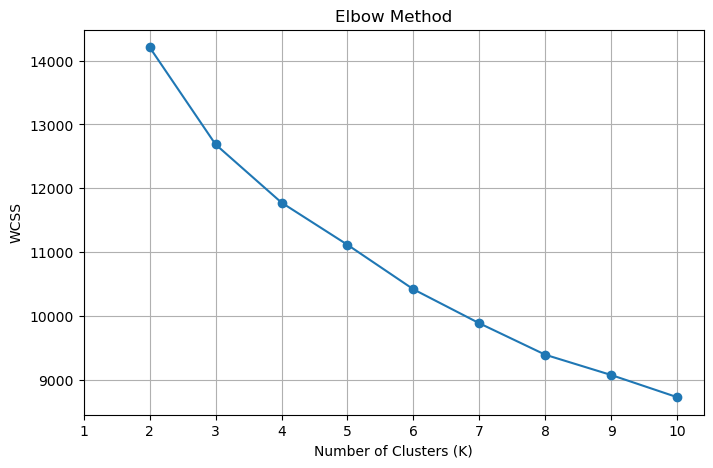

In [13]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1,11))
plt.grid(True)
plt.show()


### Elbow Method Graph

#### Observation

The Elbow Method was used to determine the optimal number of clusters by plotting WCSS (Within-Cluster Sum of Squares) against different values of K.

WCSS decreases as the number of clusters increases because data points become closer to their respective cluster centroids.

A sharp decrease in WCSS is observed from K = 2, after which the rate of decrease becomes more gradual.

This indicates that increasing the number of clusters beyond K = 2 provides only marginal improvement in reducing within-cluster variance.

Therefore, the Elbow Method suggests K = 2 as the optimal number of clusters.

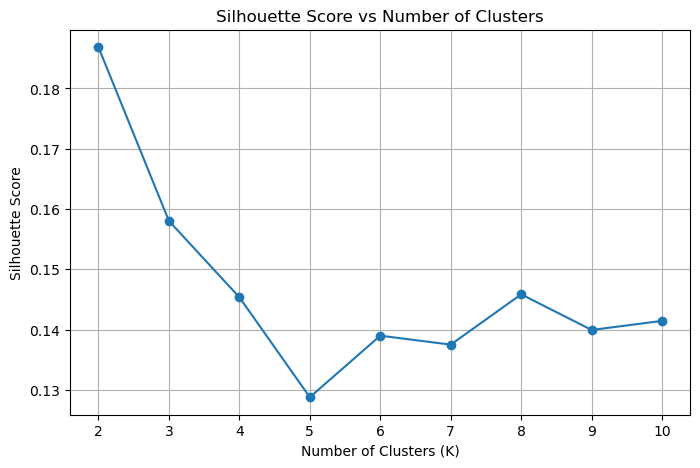

In [14]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2,11))
plt.grid(True)
plt.show()

### Silhouette Score Graph

#### Observation

The Silhouette Score was computed for different values of K to evaluate cluster quality based on cohesion and separation.
    
The highest silhouette score (0.1868) was obtained for K = 2.
    
As the number of clusters increased, the silhouette score generally decreased, indicating that the clusters became less compact and less well separated.
    
Although minor fluctuations were observed for higher values of K, none of the values exceeded the score obtained at K = 2.
    
Therefore, the Silhouette Score also suggests K = 2 as the optimal number of clusters.

#### Final Conclusion of K

Both the Elbow Method and the Silhouette Score identified K = 2 as the optimal number of clusters.

Therefore, the final KMeans model was developed using 2 clusters, as it provided the best balance between cluster compactness and separation for
grouping similar songs into meaningful cohorts.

In [15]:
## using DBSCAN for clustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

# Check clusters
set(labels_db)

{np.int64(-1),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12)}

In [16]:
valid = labels_db != -1

score_db = silhouette_score(X_scaled[valid], labels_db[valid])
print("DBSCAN Silhouette Score:", score_db)

DBSCAN Silhouette Score: -0.11701585508311531


In [17]:
##Using Hierarchial clusters
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(X_scaled)

In [18]:
score_hc = silhouette_score(X_scaled, labels_hc)
print("Hierarchical Silhouette Score:", score_hc)

Hierarchical Silhouette Score: 0.1395270157225511


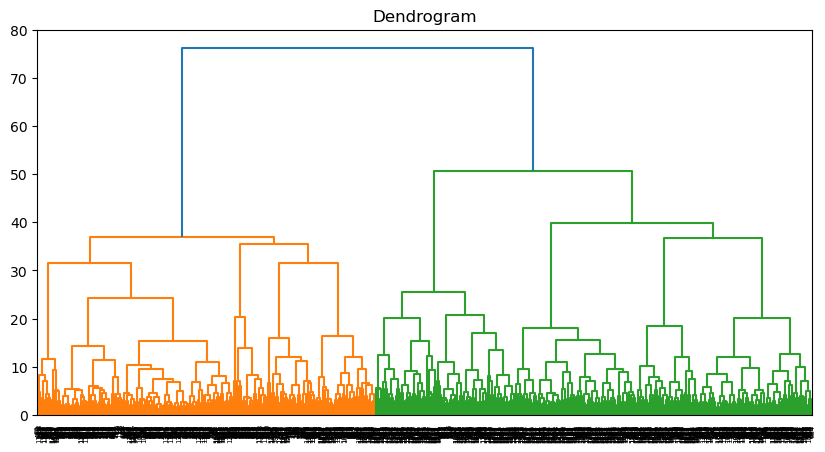

In [19]:
## Visual Representation of hoierarchial Clusters- DENDROGRAM
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

### Dendrogram Observations

The dendrogram was used to visualize the hierarchical relationship between songs and to estimate the optimal number of clusters.
    
Initially, similar songs were merged at shorter linkage distances, indicating high similarity among those observations.
    
As the linkage distance increased, larger and more distinct clusters were formed.
    
A noticeable increase in the vertical linkage distance was observed before the final merges, suggesting that combining clusters beyond this
point would merge relatively dissimilar groups.

Based on the dendrogram, 2 clusters were identified as the most appropriate choice, as cutting the dendrogram at this level produced well-separated
clusters.

The dendrogram findings were consistent with the results obtained from the Elbow Method and the Silhouette Score, both of which also 
indicated 2 clusters as the optimal choice.

In [20]:
print("KMeans:", best_score)
print("DBSCAN:", score_db)
print("Hierarchical:", score_hc)

KMeans: 0.18683102447550132
DBSCAN: -0.11701585508311531
Hierarchical: 0.1395270157225511


### Comparision of various clustering models

To determine the most suitable clustering algorithm, the performance of K-Means, DBSCAN, and Hierarchical Clustering was evaluatedusing the Silhouette
Score, which measures cluster cohesion and separation. A higher silhouette score indicates better-defined clusters.

| Algorithm               | Silhouette Score |
| ----------------------- | ---------------: |
| K-Means                 |       **0.1868** |
| Hierarchical Clustering |           0.1395 |
| DBSCAN                  |          -0.1170 |

K-Means achieved the highest silhouette score (0.1868) among all the clustering algorithms, indicating better cluster compactness and separation.
    
Hierarchical Clustering produced a positive silhouette score but performed slightly worse than K-Means, suggesting that its clusters were less well-defined.
    
DBSCAN resulted in a negative silhouette score, indicating poor cluster formation for the selected parameters and suggesting that it was not suitable for this dataset.
    
#### Therefore, K-Means was selected as the final clustering algorithm because it produced the best clustering quality and generated meaningful song cohorts


In [21]:
# From the above graph we consiser k value as 4 and applying clusteron the feature data
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

data["Cluster"] = clusters

In [22]:
#Analuysing  clusters according to the the input factors
data.groupby("Cluster").mean().round(2)

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
Cluster,,,,,,,,,,,
0,0.19,0.37,0.91,0.16,0.79,-5.51,0.10,134.45,0.48,17.92,292074.10
1,0.30,0.55,0.69,0.17,0.25,-8.17,0.05,119.17,0.67,23.16,229394.33


### We can interpret that the clusters are grouped accordingly based on the factors influencing the users



| Cluster       | Characteristics                                                          | Interpretation                                                            |
| ------------- | ------------------------------------------------------------------------ | -------------------------------------------------------- |
| **Cluster 0** | Higher energy, danceability, loudness, and tempo with lower acousticness | Energetic songs suitable for workouts, parties, and                                                                                                                                    active listening.        |
| **Cluster 1** | Higher acousticness with comparatively lower energy, loudness, and tempo | Calm, relaxing, and acoustic songs suitable for focused or casual listening. |







In [23]:
#Visulaizing Clusters 
#For better visualisation we are using PCA to reduce dimensions to 2 so that we can better visualize in a 2-Dimension

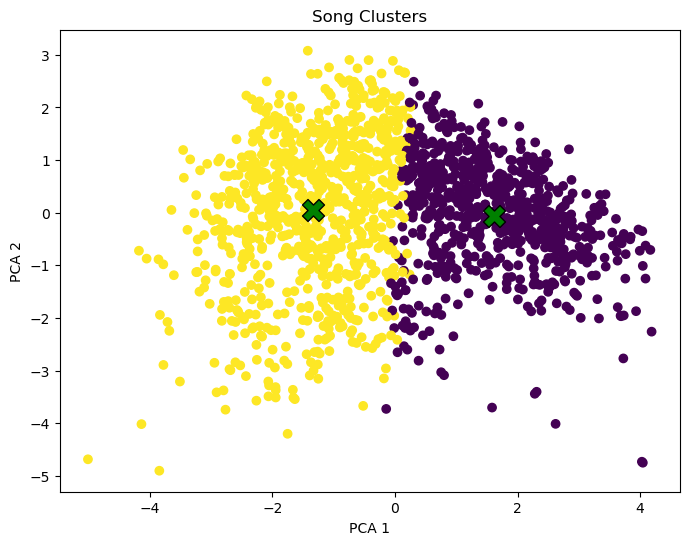

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(kmeans.cluster_centers_)


plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')

plt.scatter(centroids_pca[:,0],
            centroids_pca[:,1],
            marker='X',
            s=250,
            c='Green',
            edgecolors='black',
            label='Centroids')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Song Clusters")
plt.show()

### 📊 Scatter Plot (Cluster Visualization) – Observation

A scatter plot was used to visualize the clusters formed by the K-Means algorithm after reducing the dataset to two principal components using 
Principal Component Analysis (PCA).
    
Each point in the plot represents a song, while different colors indicate different clusters assigned by the K-Means algorithm.
    
The scatter plot shows that songs with similar audio characteristics are grouped into the same cluster.
    
Although a slight overlap exists between some data points, the clusters exhibit a reasonable level of separation, indicating that K-Means was able
to identify meaningful song cohorts.
    
This visualization provides an intuitive understanding of how songs are grouped based on their audio features and supports the effectiveness of the
clustering process.

The cluster centroids represent the average position of all songs within each cluster and act as the representative point for that cluster.

Each song is assigned to the cluster whose centroid is closest to it, minimizing the within-cluster variance.

### CONTENT-BASED RECOMMENDATION using K-MEANS CLUSTERING and COSINE SIMILARITY

After analyzing and interpreting the song clusters, the next step is to build a Content-Based Music Recommendation System. The clustering results are used to group similar songs, and cosine similarity is then applied within each cluster to recommend songs with similar audio characteristics. This approach ensures that recommendations are both relevant and computationally efficient by limiting similarity comparisons to songs belonging to the same cluster

In [25]:
##Implementing Recommendation System for the songs

### Objective

The objective of this section is to develop a content-based music recommendation system that suggests songs with similar audio characteristics to a user-selected song. After grouping similar songs using K-Means clustering, cosine similarity is applied within the same cluster to identify the most relevant recommendations. This approach improves recommendation quality by ensuring that only songs with similar feature patterns are compared.

In [26]:
print(clusters)
print(clusters.shape)
print(type(clusters))

[0 0 0 ... 1 1 1]
(1610,)
<class 'numpy.ndarray'>


In [27]:
##adding clusters to the dataframe for recommendation purpose
df["Cluster"] = clusters

In [28]:
df["Cluster"]

0       0
1       0
2       0
3       0
4       0
       ..
1605    1
1606    1
1607    1
1608    1
1609    1
Name: Cluster, Length: 1610, dtype: int32

### Cosine Similarity Matrix

Cosine similarity is computed using the standardized audio features to measure the similarity between every pair of songs. The resulting similarity matrix contains similarity scores ranging from -1 to 1, where higher values indicate greater similarity. This matrix serves as the foundation for generating personalized song recommendations.

In [29]:
from sklearn.metrics.pairwise import cosine_similarity
#calcuilating cosine similarity for recommendations
similarity_matrix = cosine_similarity(X_scaled)

In [30]:
print(similarity_matrix.shape)

(1610, 1610)


In [31]:
print(similarity_matrix)

[[ 1.          0.37740756  0.52764927 ... -0.19754169  0.05147373
  -0.19251391]
 [ 0.37740756  1.          0.92740071 ... -0.51179695 -0.53889548
  -0.36670486]
 [ 0.52764927  0.92740071  1.         ... -0.43130341 -0.49719595
  -0.35568723]
 ...
 [-0.19754169 -0.51179695 -0.43130341 ...  1.          0.7523569
   0.85983511]
 [ 0.05147373 -0.53889548 -0.49719595 ...  0.7523569   1.
   0.46324473]
 [-0.19251391 -0.36670486 -0.35568723 ...  0.85983511  0.46324473
   1.        ]]


In [32]:
def recommend_song(song_name, top_n=5):
    
    #checking Whether the song exists or not
    if song_name not in df["name"].values:
        return "Song not found."
    #Getting the index of the selected or input song
    song_index = df[df["name"] == song_name].index[0]
    #Finding the cluster of the selected/input song
    song_cluster = df.loc[song_index, "Cluster"]
    #Getting all the songs belonging to the same cluster as that of selected/input song
    cluster_songs = df[df["Cluster"] == song_cluster]
    #Getting the indices
    cluster_indices = cluster_songs.index

    similarity_scores = []
    #Calculating Similarity scores for each song
    for idx in cluster_indices:
        #ignoring the song which has been given as input or selected song
        if idx != song_index:

            similarity_scores.append(
                (idx, similarity_matrix[song_index][idx])
            )
    # sorting the songs recommended list based on the similarity songs with highest priortized songs at the top       
    similarity_scores = sorted(
    similarity_scores,
    key=lambda x: x[1],
    reverse=True
    )
    # Selecting top_N recommendations for selected song
    top_songs = similarity_scores[:top_n]

    #Extracting indices
    recommended_indices = [i[0] for i in top_songs]
    # Extracting Similarity Scores for the selected song given by the user
    scores = [round(i[1], 4) for i in top_songs]
    
    # Create recommendation dataframe with name album,cluster

    recommendations = df.loc[
    recommended_indices,
    ["name", "album","Cluster"]
    ].copy()

    # Add similarity score column
    recommendations["Similarity Score"] = scores
    return recommendations

In [33]:
# Default 5 songs are recommended when called
recommend_song(df.iloc[0,1])


,name,album,Cluster,Similarity Score
551,I'm Alright - Live,Live 1965: Music From Charlie Is My Darling (L...,0,0.8142
1382,Not Fade Away - Live,got LIVE if you want it!,0,0.8104
1471,I'm Alright - Live,Out Of Our Heads,0,0.7790
965,"Intro: Excerpt from ""Fanfare For The Common Ma...",Love You Live (Remastered 2009),0,0.7725
103,Intro - Live,A Bigger Bang (Live),0,0.7521


In [34]:
# Specifying the number of recommendations, instead of the default count
recommend_song("Happy - Live",top_n=10)

,name,album,Cluster,Similarity Score
1,Street Fighting Man - Live,Licked Live In NYC,0,0.9111
346,Before They Make Me Run - Live,From The Vault: No Security - San Jose 1999 (L...,0,0.8270
133,Ruby Tuesday - Live,Steel Wheels Live,0,0.8135
846,Time Is On My Side - Live / Remastered 2009,Still Life,0,0.8086
17,Satisfaction - Live,Licked Live In NYC,0,0.8066
4,Don’t Stop - Live,Licked Live In NYC,0,0.8058
761,Ruby Tuesday - Live / Remastered 2009,Flashpoint,0,0.7898
406,Start Me Up - Live,Sticky Fingers Live At The Fonda Theatre,0,0.7848
16,Honky Tonk Women - Live,Licked Live In NYC,0,0.7822
7,Let It Bleed - Live,Licked Live In NYC,0,0.7709


In [ ]:
#Taking the input from the user
song_name = input("Enter the song name: ")
recommend_song(song_name)

### Recommendation Function

A recommendation function is implemented to automate the recommendation process. Given a song name, the function identifies the corresponding song, determines its cluster, retrieves songs belonging to the same cluster, computes their cosine similarity scores, ranks them in descending order of similarity, and returns the top-N most similar songs.

### Generate Top-N Recommendations

For a selected song, the recommendation system returns the top-N songs with the highest cosine similarity scores from the same cluster. Restricting recommendations to the same cluster ensures that the suggested songs share similar musical characteristics while reducing unnecessary comparisons with unrelated songs.

### Generate Top-N Recommendations

For a selected song, the recommendation system returns the top-N songs with the highest cosine similarity scores from the same cluster. Restricting recommendations to the same cluster ensures that the suggested songs share similar musical characteristics while reducing unnecessary comparisons with unrelated songs.
### Sample Recommendation Output
The recommendation system displays the recommended songs along with their album names, assigned cluster, and cosine similarity scores. Higher similarity scores indicate stronger similarity between the selected song and the recommended songs.


### Results and Analysis

* Successfully grouped songs into meaningful clusters based on their audio features using K-Means clustering.
* Identified the key characteristics of each cluster through cluster profiling.
* Developed a content-based recommendation system using cosine similarity to recommend similar songs.
* The results demonstrate that audio features can effectively capture song similarity and generate relevant music recommendations.

### Final Conclusion

This project successfully developed a content-based music recommendation system using unsupervised machine learning techniques. By leveraging Spotify audio features, songs were grouped into meaningful clusters using K-Means clustering, which outperformed DBSCAN and Hierarchical Clustering based on the Silhouette Score. Cluster profiling and PCA visualization provided valuable insights into the characteristics and distribution of the identified song groups.

Building on the clustering results, Cosine Similarity was used to recommend songs with similar audio characteristics from the same cluster, resulting in relevant and efficient recommendations. Overall, the project demonstrates how clustering and similarity-based techniques can be effectively combined to build an interpretable and scalable music recommendation system based solely on song audio features.